Практика студента 4 курса ИММиКН Красина Александра

Импорт библиотек

In [ ]:
import cv2
import numpy as np
import glob
import os
import sys

Параметры работы программы

In [ ]:
#Директория с кадрами
FRAME_DIR = "seq0"
#Путь к готовому видео
OUTPUT_VIDEO_FILE = f"{FRAME_DIR}_results//{FRAME_DIR}_optical_flow.mp4"
#Директория для скриншотов
OUTPUT_SCREENSHOTS_DIR = f"{FRAME_DIR}_results//screenshots"
#Частота кадров
FPS = 30
#Сохаранять полученные данные оптического потока
SAVE_RAW_FLOW = True
#Директория для сохранённых данных
RAW_FLOW_DIR = f"{FRAME_DIR}_results//raw_flow_data"

#Шаг сетки векторов
VECTOR_GRID_STEP = 25
#Порог модуля вектора
VECTOR_MAGNITUDE_THRESH = 0.5
#Масштаб вектора
VECTOR_SCALE = 1.0
#Длинна наконечника стрелки (доля от длинны вектора)
ARROW_TIP_LENGTH = 0.2

#Смешивание исходного кадра(ALPHA) и цветовой кадры(BETA)
ALPHA = 0.6
BETA = 0.4

#Кадры, которые нужно сохранить как скриншоты
SCREENSHOT_FRAMES = [10, 20, 28, 38, 48]


FARNEBACK_PARAMS = {
    'pyr_scale': 0.5,    # масштаб пирамиды (<1)
    'levels': 3,         # количество уровней пирамиды
    'winsize': 15,       # размер окна (нечётное)
    'iterations': 3,     # число итераций на каждом уровне
    'poly_n': 5,         # размер окна полиномиальной аппроксимации (нечётное)
    'poly_sigma': 1.2,   # стандартное отклонение для полиномов
    'flags': 0           # можно добавить OPTFLOW_FARNEBACK_GAUSSIAN
}

Инициализация

In [ ]:
os.makedirs(OUTPUT_SCREENSHOTS_DIR, exist_ok=True)
frame_paths = sorted(glob.glob(os.path.join(FRAME_DIR, "*.png")))

first_frame = cv2.imread(frame_paths[0])
height, width = first_frame.shape[:2]
fourcc = cv2.VideoWriter_fourcc(*'mp4v')   # кодек MP4
out_video = cv2.VideoWriter(OUTPUT_VIDEO_FILE, fourcc, FPS, (width, height))

if SAVE_RAW_FLOW:
    os.makedirs(RAW_FLOW_DIR, exist_ok=True)

Основной цикл

In [ ]:
prev_gray = cv2.cvtColor(first_frame, cv2.COLOR_BGR2GRAY)


for i in range(1, len(frame_paths)):
    current_frame = cv2.imread(frame_paths[i])
    current_gray = cv2.cvtColor(current_frame, cv2.COLOR_BGR2GRAY)
    flow = cv2.calcOpticalFlowFarneback(prev_gray,
                                         current_gray,
                                         None,
                                         **FARNEBACK_PARAMS)
    dx = flow[..., 0]
    dy = flow[..., 1]

    magnitude, angle_rad = cv2.cartToPolar(dx, dy)
    magnitude_norm = cv2.normalize(magnitude, None, 0, 255, cv2.NORM_MINMAX)
    magnitude_norm = magnitude_norm.astype(np.uint8)

    hue = (angle_rad * 180 / np.pi) / 2
    hue = hue.astype(np.uint8)

    hsv = np.zeros((height, width, 3), dtype=np.uint8)
    hsv[..., 0] = hue
    hsv[..., 1] = 255
    hsv[..., 2] = magnitude_norm

    flow_bgr = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)
    overlay = cv2.addWeighted(current_frame, ALPHA, flow_bgr, BETA, 0)

    for y in range(0, height, VECTOR_GRID_STEP):
        for x in range(0, width, VECTOR_GRID_STEP):
            vec_dx = flow[y, x, 0]
            vec_dy = flow[y, x, 1]
            mag = np.sqrt(vec_dx**2 + vec_dy**2)
            if mag < VECTOR_MAGNITUDE_THRESH: #Отброс шума
                continue
            end_x = int(x + vec_dx * VECTOR_SCALE)
            end_y = int(y + vec_dy * VECTOR_SCALE)

            if vec_dx > 1.0:
                color = (0, 0, 255)
            elif vec_dx < -1.0:
                color = (255, 0, 0)
            else:
                color = (0, 255, 0)
            cv2.arrowedLine(overlay, (x, y), (end_x, end_y), color, 
                            thickness=1, tipLength=ARROW_TIP_LENGTH)
    
    if i in SCREENSHOT_FRAMES:
        screenshot_name = os.path.join(OUTPUT_SCREENSHOTS_DIR, f"frame_{i:04d}.png")
        cv2.imwrite(screenshot_name, overlay)

    if SAVE_RAW_FLOW:
        np.save(os.path.join(RAW_FLOW_DIR, f"flow_{i:04d}.npy"), flow)
        np.save(os.path.join(RAW_FLOW_DIR, f"mag_{i:04d}.npy"), magnitude)
        np.save(os.path.join(RAW_FLOW_DIR, f"angle_{i:04d}.npy"), angle_rad)

    out_video.write(overlay)
    prev_gray = current_gray


Завершение

In [ ]:
out_video.release()
cv2.destroyAllWindows()

Пример скриншота.

Векторы имеют цветовое кодирование:
Синий - движение влево
Красный - движение вправо
Зелёный - вертикальное движение

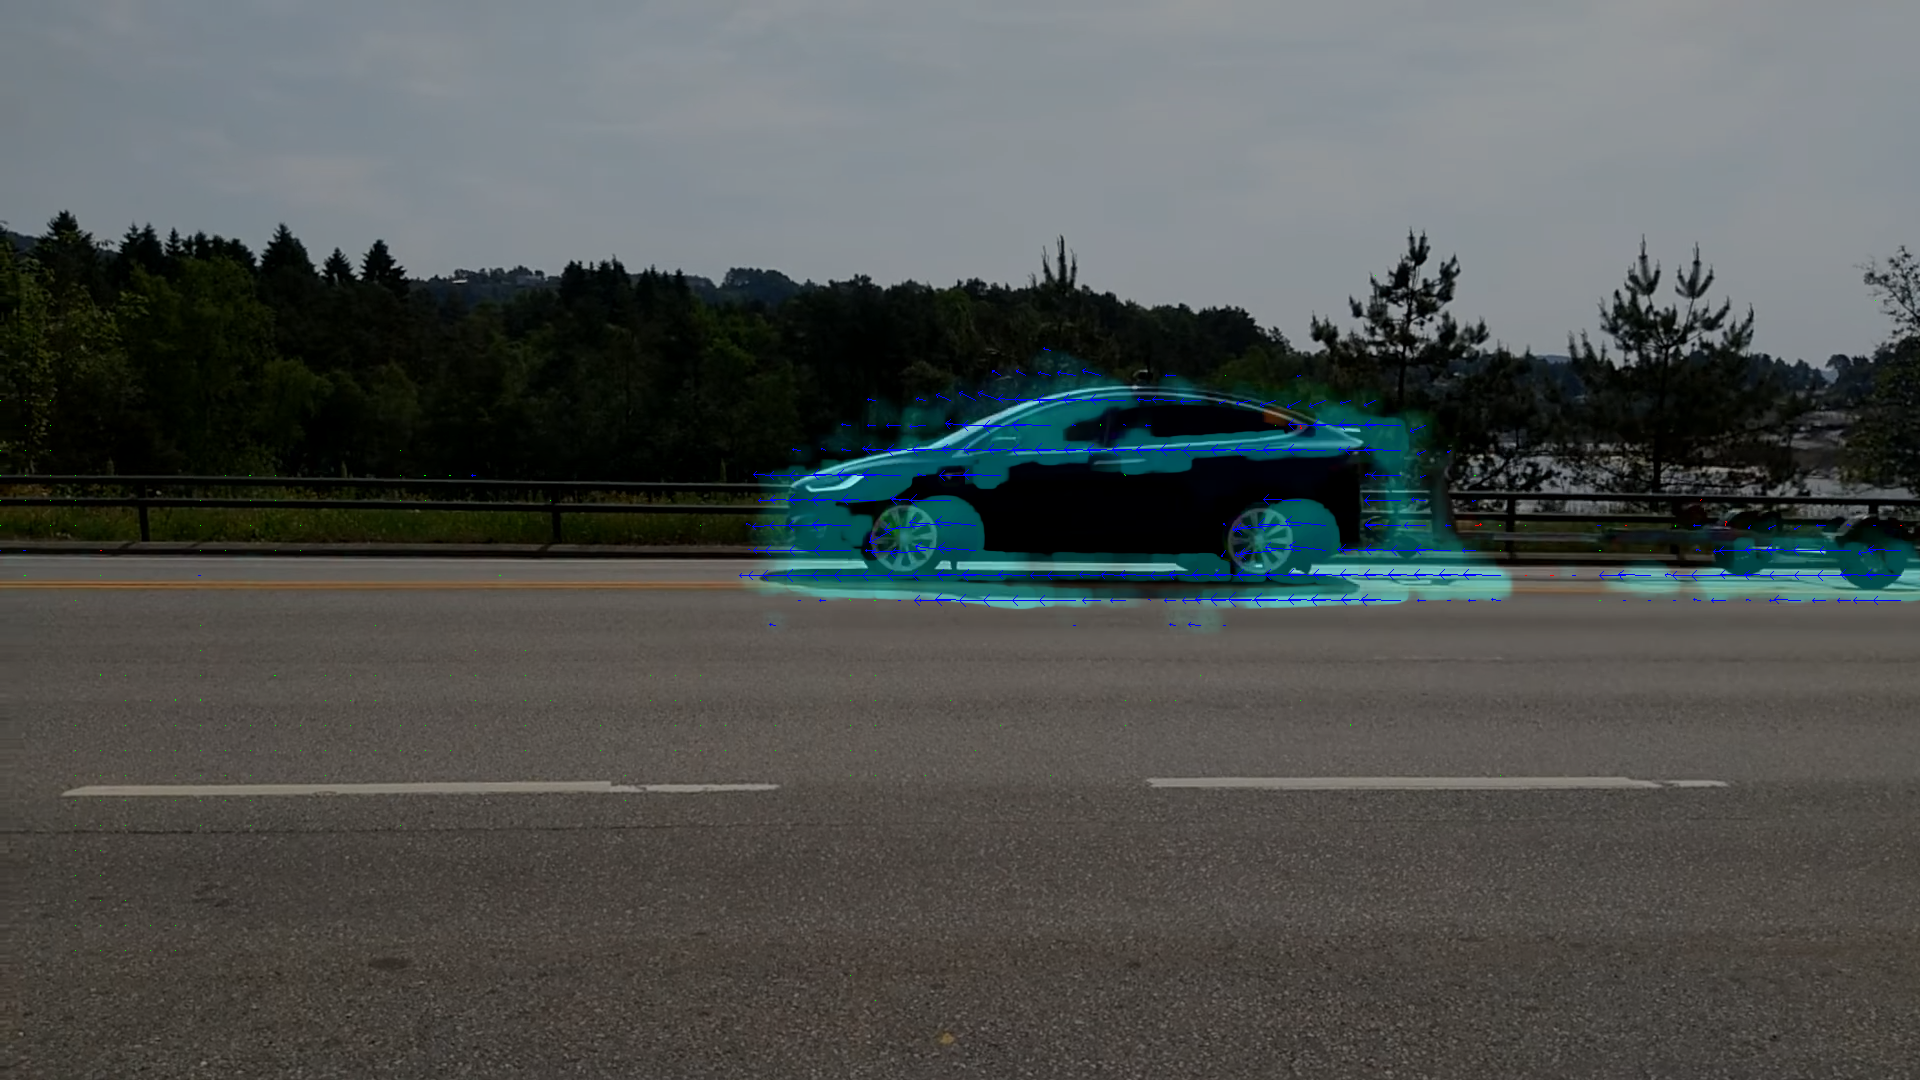
